This notebook contains code for generating synthetic datasets using the experiments package.

Generate dataset with normalization: L2 normalization, Min-Max normalization, degree 5, sample 100.

In [1]:
from experiments.DatasetManager import DatasetManager
import jax.numpy as jnp
import experiments.constants as const_exp

# Create a DatasetManager instance
dataset_manager = DatasetManager(
    x=jnp.linspace(0, 2 * jnp.pi, 100),
    x_test=jnp.linspace(-2 * jnp.pi, 0, 100),
    num_sample=100,
    degree=12,
    normalization_strategies=[
        const_exp.L2_NORMALIZATION,
        const_exp.MIN_MAX_NORMALIZATION,
        const_exp.HALF_RANGE_NORMALIZATION]
)

# Save the generated dataset to a JSON file
dataset_manager.save_dataset_to_json('dataset_12degree_100sample.json')

Load the dataset from json file.

In [2]:
from experiments.DatasetManager import DatasetManager
import jax.numpy as jnp
import experiments.constants as const_exp

dataset_manager_loader = DatasetManager(
    x=None,
    x_test=None,
    num_sample=None,
    degree=None,
    normalization_strategies=None,
    json_file_path='dataset_12degree_100sample.json' # Path to the load dataset file
)

Vizualization the dataset function.

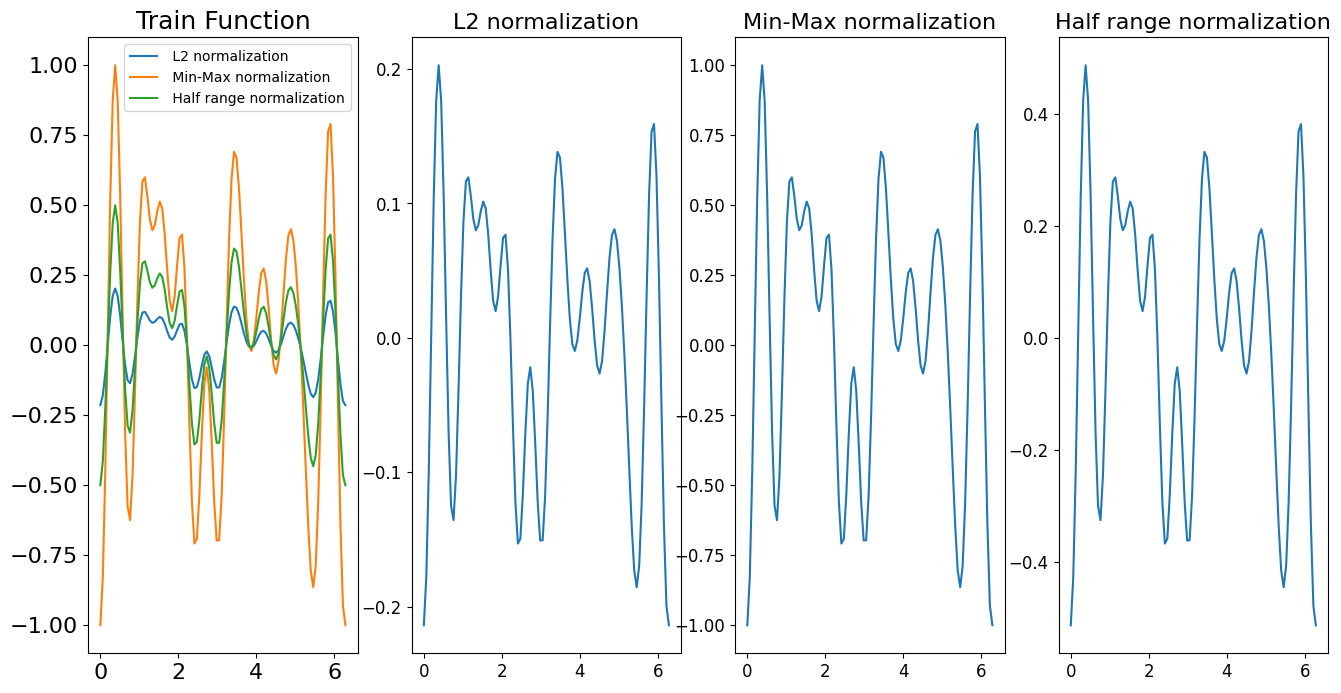

In [9]:
import matplotlib.pyplot as plt

normalization_strategies = [const_exp.L2_NORMALIZATION,
                            const_exp.MIN_MAX_NORMALIZATION,
                            const_exp.HALF_RANGE_NORMALIZATION]

# Plot the results
fig, axs = plt.subplots(1, len(normalization_strategies)+1 , figsize=(16, 8))
for idx,normalization in enumerate(normalization_strategies):
    y_series, y_series_test = dataset_manager_loader.get_series(normalization)
    axs[0].plot(dataset_manager_loader.x, y_series[0] , label=f" {normalization}")
    axs[idx+1].plot(dataset_manager_loader.x, y_series_test[0] , label=f"Test Function normalization: {normalization}")
    axs[idx+1].set_title(f"{normalization}", fontsize=16)
    axs[idx + 1].set_xlabel("", fontsize=16)
    axs[idx + 1].set_ylabel("", fontsize=16)
    axs[idx + 1].tick_params(axis='both', which='major', labelsize=12)


axs[0].legend()
axs[0].set_title("Train Function", fontsize=18)
axs[0].set_xlabel("", fontsize=16)
axs[0].set_ylabel("", fontsize=16)
axs[0].tick_params(axis='both', which='major', labelsize=16)

filename = f"Normalization.png"
plt.savefig(filename)
plt.show()

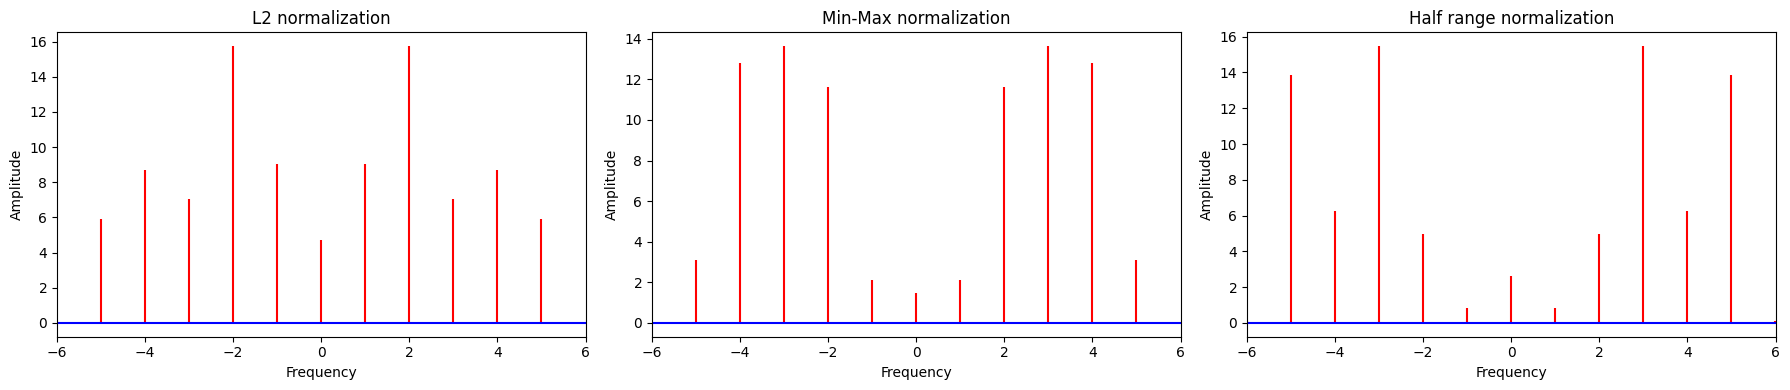

In [28]:
from experiments.plotting import compute_dft_and_plot_amplitude_spectra

normalization_strategies = [const_exp.L2_NORMALIZATION,
                            const_exp.MIN_MAX_NORMALIZATION,
                            const_exp.HALF_RANGE_NORMALIZATION]

y_series, y_series_test = zip(*[dataset_manager_loader.get_series(normalization) for normalization in normalization_strategies])
compute_dft_and_plot_amplitude_spectra(y_series[0], dataset_manager_loader.x, normalization_strategies, 6)

In [1]:
from experiments.DatasetManager import DatasetManager
import jax.numpy as jnp
import experiments.constants as const_exp

from experiments.DatasetManager import DatasetManager
import jax.numpy as jnp
import experiments.constants as const_exp

# Create a DatasetManager instance
dataset_manager = DatasetManager(
    x=jnp.linspace(0, 2 * jnp.pi, 1000),
    x_test=jnp.linspace(-2 * jnp.pi, 0, 1000),
    num_sample=100,
    degree=5,
    normalization_strategies=[
        const_exp.L2_NORMALIZATION,
        const_exp.MIN_MAX_NORMALIZATION,
        const_exp.HALF_RANGE_NORMALIZATION]
)

# Save the generated dataset to a JSON file
#dataset_manager.save_dataset_to_json('dataset_5degree_100sa.json')

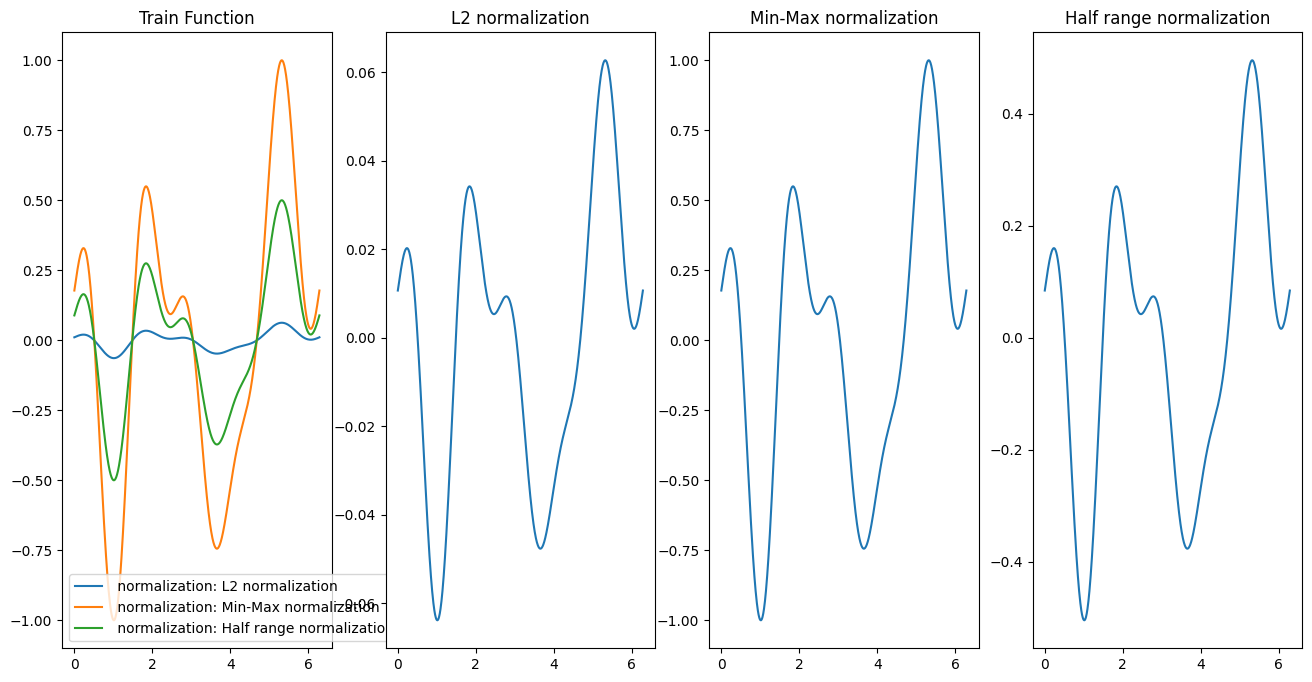

In [2]:
import matplotlib.pyplot as plt

normalization_strategies = [const_exp.L2_NORMALIZATION,
                            const_exp.MIN_MAX_NORMALIZATION,
                            const_exp.HALF_RANGE_NORMALIZATION]

# Plot the results
fig, axs = plt.subplots(1, len(normalization_strategies)+1 , figsize=(16, 8))
for idx,normalization in enumerate(normalization_strategies):
    y_series, y_series_test = dataset_manager.get_series(normalization)
    axs[0].plot(dataset_manager.x, y_series[0] , label=f" normalization: {normalization}")
    axs[idx+1].plot(dataset_manager.x, y_series_test[0] , label=f"Test Function normalization: {normalization}")
    axs[idx+1].set_title(f"{normalization}")
    #axs[idx+1].legend()

axs[0].legend()
axs[0].set_title("Train Function")

plt.show()